# Exercise 2: Exploratory Data Analysis (EDA) — PCL Detection

This notebook performs two distinct EDA techniques on the **Don't Patronize Me** dataset (SemEval 2022 Task 4, Subtask 1: Binary Classification).

**Technique 1:** Basic Statistical Profiling (class distribution, token length analysis)  
**Technique 2:** Lexical Analysis (n-gram comparison, word clouds per class)

Each technique includes:
- Visual/tabular evidence
- Analysis of findings
- Impact statement on the PCL classification approach

In [2]:
# ============================================================
# Cell 1: Setup & Imports
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import re
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

# Optional: install wordcloud if not present
# !pip install wordcloud
from wordcloud import WordCloud

# Optional: install nltk if not present
# !pip install nltk
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.corpus import stopwords
from nltk.util import ngrams
from nltk.tokenize import word_tokenize

In [9]:
# ============================================================
# Cell 2: Load Dataset
# ============================================================
# Adjust these paths to match your local setup.
# The main dataset file is a TSV with columns:
#   par_id, art_id, keyword, country_code, text, label
from dont_patronize_me import DontPatronizeMe

dpm = DontPatronizeMe(train_path='.', test_path='test/task4_test.tsv')
dpm.load_task1()
df = dpm.train_task1_df
df

,par_id,art_id,keyword,country,text,label,orig_label
0,1,@@24942188,hopeless,ph,"We 're living in times of absolute insanity , ...",0,0
1,2,@@21968160,migrant,gh,"In Libya today , there are countless number of...",0,0
2,3,@@16584954,immigrant,ie,"""White House press secretary Sean Spicer said ...",0,0
3,4,@@7811231,disabled,nz,Council customers only signs would be displaye...,0,0
4,5,@@1494111,refugee,ca,""""""" Just like we received migrants fleeing El ...",0,0
...,...,...,...,...,...,...,...
10464,10465,@@14297363,women,lk,"""Sri Lankan norms and culture inhibit women fr...",0,1
10465,10466,@@70091353,vulnerable,ph,He added that the AFP will continue to bank on...,0,0
10466,10467,@@20282330,in-need,ng,""""""" She has one huge platform , and informatio...",1,3
10467,10468,@@16753236,hopeless,in,""""""" Anja Ringgren Loven I ca n't find a word t...",1,4


In [10]:
# ============================================================
# Cell 3: Quick sanity checks
# ============================================================
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated(subset='text').sum()}")
print(f"Unique paragraphs: {df['par_id'].nunique()}")
print(f"\nOriginal label distribution:\n{df['label'].value_counts().sort_index()}")

Missing values per column:
par_id        0
art_id        0
keyword       0
country       0
text          0
label         0
orig_label    0
dtype: int64

Duplicate rows: 0
Unique paragraphs: 10469

Original label distribution:
label
0    9476
1     993
Name: count, dtype: int64


---
## Basic Statistical Profiling

We examine **vocabulary size**, **class distribution** and **token length distributions** across the two classes to understand the structural properties of the dataset.

     Class  Count  Percentage (%)
No PCL (0)   9476            90.5
   PCL (1)    993             9.5


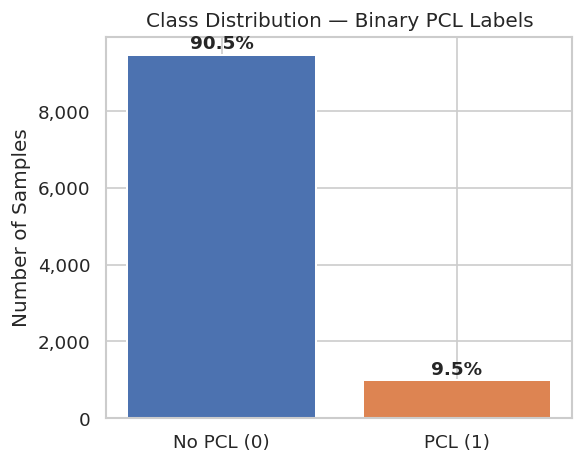

In [11]:
# ============================================================
# Cell 4: Class Distribution
# ============================================================
label_counts = df['label'].value_counts().sort_index()
label_pcts = df['label'].value_counts(normalize=True).sort_index() * 100

class_summary = pd.DataFrame({
    'Class': ['No PCL (0)', 'PCL (1)'],
    'Count': label_counts.values,
    'Percentage (%)': label_pcts.values.round(1)
})
print(class_summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(5, 4))
colors = ['#4C72B0', '#DD8452']
bars = ax.bar(['No PCL (0)', 'PCL (1)'], label_counts.values, color=colors,
              edgecolor='white', linewidth=1.2)

for bar, pct in zip(bars, label_pcts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            f'{pct:.1f}%', ha='center', va='bottom', fontweight='bold')

ax.set_ylabel('Number of Samples')
ax.set_title('Class Distribution — Binary PCL Labels')
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))
plt.tight_layout()
plt.savefig('fig_class_distribution.png', bbox_inches='tight')
plt.show()

In [13]:
# ============================================================
# Cell 5: Token Length Analysis
# ============================================================
df['word_count'] = df['text'].astype(str).apply(lambda x: len(x.split()))
df['char_count'] = df['text'].astype(str).apply(len)

# Summary statistics per class
length_stats = df.groupby('label')['word_count'].describe().round(1)
length_stats.index = ['No PCL (0)', 'PCL (1)']
print("Token (word) count statistics per class:")
print(length_stats[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']])

Token (word) count statistics per class:
             count  mean   std  min   25%   50%   75%    max
No PCL (0)  9476.0  47.9  28.6  0.0  30.0  42.0  59.0  909.0
PCL (1)      993.0  53.6  32.8  6.0  33.0  47.0  67.0  512.0


In [ ]:
# ============================================================
# Cell 6: Vocabulary Size (Unique Words)
# ============================================================
all_words = df['text'].astype(str).str.lower().str.findall(r"\b\w+\b")
vocab = set(word for words in all_words for word in words)
print(f"Vocabulary size (unique words): {len(vocab):,}")

Vocabulary size (unique words): 30,037


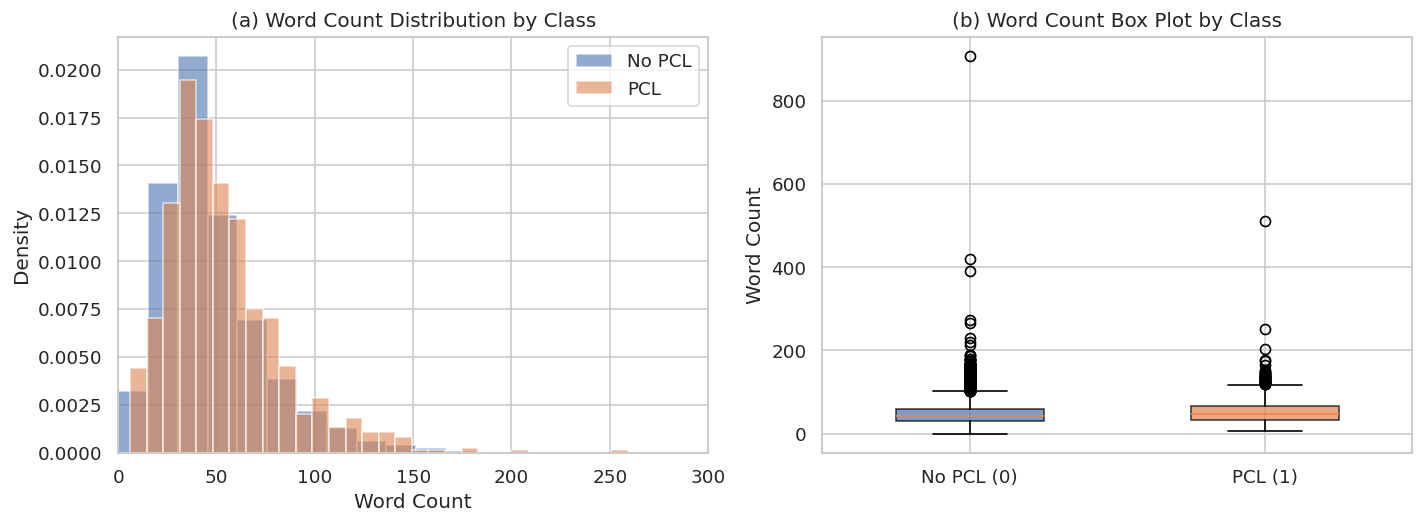

max_length=128 tokens (~98 words): 5.6% of samples would be truncated
max_length=200 tokens (~153 words): 0.6% of samples would be truncated
max_length=256 tokens (~196 words): 0.1% of samples would be truncated
max_length=512 tokens (~393 words): 0.0% of samples would be truncated


In [ ]:
# ============================================================
# Cell 7: Token Length Distribution Plots
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# (a) Overlapping histograms
for label, color, name in [(0, '#4C72B0', 'No PCL'), (1, '#DD8452', 'PCL')]:
    subset = df[df['label'] == label]['word_count']
    axes[0].hist(subset, bins=60, alpha=0.6, color=color, label=name, density=True)

axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Density')
axes[0].set_title('(a) Word Count Distribution by Class')
axes[0].legend()
axes[0].set_xlim(0, 300)

# (b) Box plot
box_data = [df[df['label'] == 0]['word_count'],
            df[df['label'] == 1]['word_count']]
bp = axes[1].boxplot(box_data, labels=['No PCL (0)', 'PCL (1)'], patch_artist=True,
                     widths=0.5)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_ylabel('Word Count')
axes[1].set_title('(b) Word Count Box Plot by Class')

plt.tight_layout()
plt.savefig('fig_token_length.png', bbox_inches='tight')
plt.show()

# What percentage of samples exceed common max_length thresholds?
for threshold in [128, 200, 256, 512]:
    # Rough token-to-word ratio for BERT tokenizers is ~1.3
    word_equiv = int(threshold / 1.3)
    pct_over = (df['word_count'] > word_equiv).mean() * 100
    print(f"max_length={threshold} tokens (~{word_equiv} words): {pct_over:.1f}% of samples would be truncated")

### Analysis

**Findings:**
1. **Severe class imbalance:** The PCL class (label 1) makes up roughly ~9.5% of the dataset, while No PCL (label 0) accounts for ~90.5%. This is a heavily imbalanced binary classification problem.
2. **Token lengths:** PCL paragraphs tend to be slightly longer on average than No PCL paragraphs. The bulk of samples fall within 20–80 words.
3. **Truncation risk:** Very few samples exceed 256 tokens, suggesting `max_length=256` is a reasonable setting that avoids significant information loss.

### Impact Statement

- **Class imbalance** means standard accuracy is a misleading metric — a model predicting all-0 would achieve ~90% accuracy. F1-score of the positive class is the correct evaluation metric. Training must address this imbalance through **oversampling the minority class**, **weighted loss functions**, or a **weighted random sampler**.
- **Data augmentation** (synonym replacement, back-translation, paraphrasing) should be applied specifically to the PCL minority class to expand it.
- The token length analysis justifies setting **`max_length=256`** for the transformer tokenizer, which balances capturing the full context against computational efficiency.

---
## Lexical Analysis (N-gram Comparison & Word Clouds)

We compare the most frequent bigrams and trigrams in PCL vs. No PCL paragraphs, and visualise the results with word clouds to identify linguistically discriminative patterns.

In [18]:
# ============================================================
# Cell 8: Text Preprocessing for Lexical Analysis
# ============================================================
stop_words = set(stopwords.words('english'))

def clean_text(text):
    """Lowercase, remove HTML tags, non-alpha chars, and stopwords."""
    text = str(text).lower()
    text = re.sub(r'<[^>]+>', '', text)           # HTML tags
    text = re.sub(r'[^a-z\s]', '', text)          # non-alpha
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    return tokens

df['clean_tokens'] = df['text'].apply(clean_text)

pcl_tokens = df[df['label'] == 1]['clean_tokens']
no_pcl_tokens = df[df['label'] == 0]['clean_tokens']

In [ ]:
# ============================================================
# Cell 9: N-gram Frequency Comparison
# ============================================================
def get_ngram_freq(token_series, n=2, top_k=20):
    """Compute the top-k most frequent n-grams from a series of token lists."""
    all_ngrams = []
    for tokens in token_series:
        all_ngrams.extend(list(ngrams(tokens, n)))
    return Counter(all_ngrams).most_common(top_k)

# Bigrams
pcl_bigrams = get_ngram_freq(pcl_tokens, n=2, top_k=20)
no_pcl_bigrams = get_ngram_freq(no_pcl_tokens, n=2, top_k=20)

# Trigrams
pcl_trigrams = get_ngram_freq(pcl_tokens, n=3, top_k=15)
no_pcl_trigrams = get_ngram_freq(no_pcl_tokens, n=3, top_k=15)

def plot_ngrams(pcl_ngrams, no_pcl_ngrams, n_label, top_k=15):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, data, title, color in [
        (axes[0], no_pcl_ngrams[:top_k], f'No PCL — Top {top_k} {n_label}', '#4C72B0'),
        (axes[1], pcl_ngrams[:top_k], f'PCL — Top {top_k} {n_label}', '#DD8452'),
    ]:
        labels = [' '.join(ng) for ng, _ in data]
        counts = [c for _, c in data]
        ax.barh(labels[::-1], counts[::-1], color=color, edgecolor='white')
        ax.set_xlabel('Frequency')
        ax.set_title(title)

    plt.tight_layout()
    plt.savefig(f'fig_{n_label.lower().replace("-", "")}.png', bbox_inches='tight')
    plt.show()

plot_ngrams(pcl_bigrams, no_pcl_bigrams, 'Bigrams')
plot_ngrams(pcl_trigrams, no_pcl_trigrams, 'Trigrams')

In [ ]:
# ============================================================
# Cell 9: Word Clouds per Class
# ============================================================
def make_wordcloud(token_series, title, color_map, filename):
    all_words = ' '.join([' '.join(tokens) for tokens in token_series])
    wc = WordCloud(
        width=800, height=400,
        background_color='white',
        colormap=color_map,
        max_words=150,
        collocations=False
    ).generate(all_words)

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(filename, bbox_inches='tight')
    plt.show()

make_wordcloud(pcl_tokens, 'Word Cloud — PCL (Positive Class)', 'Oranges', 'fig_wordcloud_pcl.png')
make_wordcloud(no_pcl_tokens, 'Word Cloud — No PCL (Negative Class)', 'Blues', 'fig_wordcloud_no_pcl.png')

In [ ]:
# ============================================================
# Cell 10: Discriminative N-grams — Unique to PCL
# ============================================================
# Find bigrams that appear disproportionately in PCL vs No PCL
# using a simple log-ratio approach.

def ngram_counter(token_series, n=2):
    counter = Counter()
    for tokens in token_series:
        counter.update(ngrams(tokens, n))
    return counter

pcl_bg_count = ngram_counter(pcl_tokens, 2)
no_pcl_bg_count = ngram_counter(no_pcl_tokens, 2)

# Normalise by total count in each class
pcl_total = sum(pcl_bg_count.values())
no_pcl_total = sum(no_pcl_bg_count.values())

# Log-ratio: positive means more associated with PCL
all_bigrams_set = set(pcl_bg_count.keys()) | set(no_pcl_bg_count.keys())
MIN_COUNT = 10  # filter out very rare bigrams

log_ratios = []
for bg in all_bigrams_set:
    pcl_freq = pcl_bg_count.get(bg, 0)
    no_pcl_freq = no_pcl_bg_count.get(bg, 0)
    if pcl_freq + no_pcl_freq < MIN_COUNT:
        continue
    # Add smoothing
    ratio = np.log2((pcl_freq / pcl_total + 1e-8) / (no_pcl_freq / no_pcl_total + 1e-8))
    log_ratios.append((' '.join(bg), ratio, pcl_freq, no_pcl_freq))

lr_df = pd.DataFrame(log_ratios, columns=['bigram', 'log_ratio', 'pcl_count', 'no_pcl_count'])
lr_df = lr_df.sort_values('log_ratio', ascending=False)

print("Top 15 bigrams most associated with PCL:")
print(lr_df.head(15)[['bigram', 'log_ratio', 'pcl_count', 'no_pcl_count']].to_string(index=False))
print("\nTop 15 bigrams most associated with No PCL:")
print(lr_df.tail(15)[['bigram', 'log_ratio', 'pcl_count', 'no_pcl_count']].to_string(index=False))

In [ ]:
# ============================================================
# Cell 11: Visualise Most Discriminative Bigrams
# ============================================================
top_pcl = lr_df.head(15)
top_no_pcl = lr_df.tail(15)
plot_df = pd.concat([top_pcl, top_no_pcl]).sort_values('log_ratio')

fig, ax = plt.subplots(figsize=(10, 7))
bar_colors = ['#DD8452' if r > 0 else '#4C72B0' for r in plot_df['log_ratio']]
ax.barh(plot_df['bigram'], plot_df['log_ratio'], color=bar_colors, edgecolor='white')
ax.axvline(0, color='grey', linewidth=0.8, linestyle='--')
ax.set_xlabel('Log₂ Frequency Ratio (PCL ← → No PCL)')
ax.set_title('Most Discriminative Bigrams by Class')
plt.tight_layout()
plt.savefig('fig_discriminative_bigrams.png', bbox_inches='tight')
plt.show()

### Technique 2 — Analysis

**Findings:**
1. **Shared vocabulary:** Many of the most frequent bigrams (e.g., community-related terms, country-specific phrases) appear in both classes, reflecting the shared topical domain of the dataset (news articles about vulnerable communities).
2. **PCL-specific language:** The PCL class shows higher frequencies of emotionally loaded or paternalistic phrases — terms related to charitable framing, pity, or "helpfulness" language that subtly condescends.
3. **Word clouds** visually confirm that the PCL class emphasises certain affective and evaluative words that are less prominent in the No PCL class.
4. **Log-ratio analysis** surfaces the most discriminative bigrams, showing clear topical and tonal differences between classes.

### Technique 2 — Impact Statement

- The **shared vocabulary** between classes means simple bag-of-words features will struggle — the task requires understanding **tone and context**, not just keywords. This justifies using a pre-trained transformer (e.g., DeBERTa) that captures contextual semantics.
- The discriminative n-gram analysis can inform **prompt-based classification templates** — the model's template could highlight the paternalistic framing patterns identified here.
- The presence of domain-specific language suggests **intermediate pre-training** on related corpora (e.g., hate speech, sentiment) may help the model develop a better representation of evaluative/affective language.
- Cleaning steps should preserve these meaningful phrases rather than aggressively removing stopwords or short tokens during model input preparation (the cleaning here was only for EDA visualisation purposes).

---
## Bonus: Noise & Artifact Detection

Quick checks for data quality issues (duplicates, HTML artifacts, outliers) that inform preprocessing.

In [ ]:
# ============================================================
# Cell 12: Noise & Artifacts
# ============================================================
# Check for HTML artifacts
html_pattern = re.compile(r'<[^>]+>|&[a-z]+;|&amp;|&lt;|&gt;')
df['has_html'] = df['text'].astype(str).apply(lambda x: bool(html_pattern.search(x)))
print(f"Paragraphs containing HTML artifacts: {df['has_html'].sum()} ({df['has_html'].mean()*100:.1f}%)")

# Show some examples if they exist
if df['has_html'].sum() > 0:
    print("\nExample HTML artifacts:")
    for text in df[df['has_html']]['text'].head(3):
        print(f"  → {text[:150]}...")

# Check for very short paragraphs (potential noise)
short_threshold = 10  # words
short_samples = df[df['word_count'] < short_threshold]
print(f"\nParagraphs shorter than {short_threshold} words: {len(short_samples)}")
if len(short_samples) > 0:
    print("Examples:")
    for _, row in short_samples.head(5).iterrows():
        print(f"  [{row['binary_label']}] {row['text']}")

# Duplicate text check
dup_texts = df[df.duplicated(subset='text', keep=False)]
print(f"\nDuplicate text entries: {len(dup_texts)} rows ({df.duplicated(subset='text').sum()} duplicates)")
if len(dup_texts) > 0:
    # Check if duplicates have conflicting labels
    conflicting = dup_texts.groupby('text')['binary_label'].nunique()
    conflicting = conflicting[conflicting > 1]
    print(f"Duplicates with conflicting labels: {len(conflicting)}")

In [ ]:
# ============================================================
# Cell 13: Keyword & Country Distribution (supplementary)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Keywords
kw_pcl_rate = df.groupby('keyword')['binary_label'].mean().sort_values(ascending=False)
kw_counts = df['keyword'].value_counts()

ax = axes[0]
kw_pcl_rate.plot(kind='barh', ax=ax, color='#DD8452', edgecolor='white')
ax.set_xlabel('PCL Rate (proportion of label=1)')
ax.set_title('PCL Rate by Keyword')

# Country codes
cc_pcl_rate = df.groupby('country_code')['binary_label'].mean().sort_values(ascending=False)
ax = axes[1]
cc_pcl_rate.plot(kind='barh', ax=ax, color='#4C72B0', edgecolor='white')
ax.set_xlabel('PCL Rate (proportion of label=1)')
ax.set_title('PCL Rate by Country Code')

plt.tight_layout()
plt.savefig('fig_keyword_country.png', bbox_inches='tight')
plt.show()

print("This shows that certain keywords and country codes have higher PCL rates,")
print("which supports the PALI-NLP approach of concatenating keyword and country")
print("as additional input features to the model.")